In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import shap

df = pd.read_csv("ico-data.csv", encoding='ISO-8859-1')  # Ensures panda can read file.
print('Missing values: ', df.isnull().sum())


Missing values:  Case Status                    0
Legislation                    0
ICOCaseRef                     0
Received Datetime              0
Received Year                  0
Received FY                    0
Received Qtr                   0
Received FY Month              0
Completed Date                 0
Completed Year                 0
Completed FY                   0
Completed Qtr                  0
FY Completed Month             0
Completed Financial Week       0
Sector                         0
SubSector                      0
Submitted About Account        0
Decision                       0
DecisionDetail1                0
DecisionDetail2             3383
ISCyberIncident             3383
dtype: int64


In [ ]:
def data_preprocess(df):
    # Using the sum function to check for missing values in the data set.
    columns_drop = ['ICOCaseRef', 'Received Year','Received FY','Received Qtr','Received FY Month','Completed Year', 'Completed FY', 'Completed Qtr','FY Completed Month']
    df_clean = df.drop(columns=[col for col in columns_drop if col in df.columns])   
    df_clean.head()
    return df_clean

df_clean = data_preprocess(df)

This next part displays the sectors and sub sectors that suffer the most cyber incidents.  Each graph details the percentage of incidents that were found to be cyber incidents, giving an insight into which sectors are most vulnerable.  This information is important as it can be used for feature engineering.

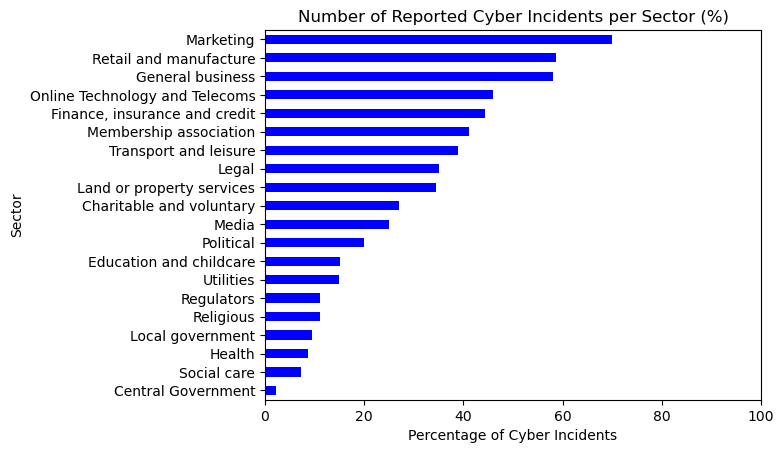

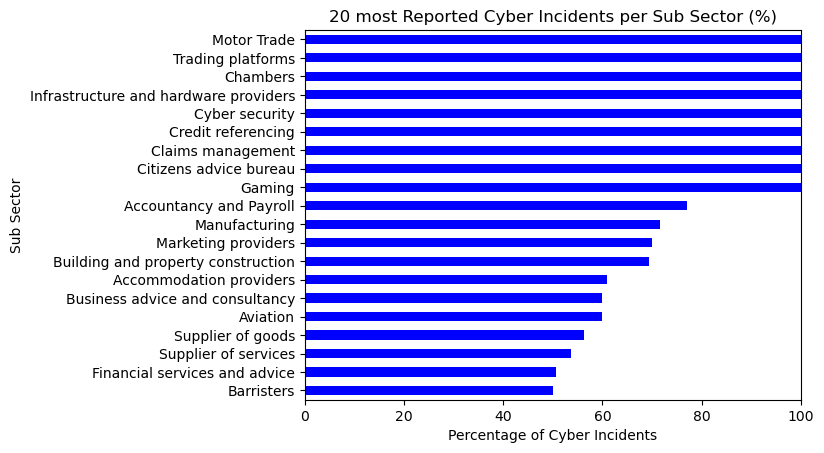

In [3]:
cyber_yes = df_clean[df_clean['ISCyberIncident'] == 'Yes']
sector_total = df_clean['Sector'].value_counts()
sector_cyber = cyber_yes['Sector'].value_counts()
sector_cyber_rate = (sector_cyber / sector_total).fillna(0) * 100
top_20_sectors = sector_cyber_rate.sort_values(ascending=False).head(20)

top_20_sectors.sort_values().plot(kind='barh', color='blue')
plt.xlabel('Percentage of Cyber Incidents')
plt.ylabel('Sector')
plt.title('Number of Reported Cyber Incidents per Sector (%)')
plt.xlim(0,100)
plt.show()

sub_cyber_yes = df_clean[df_clean['ISCyberIncident'] == 'Yes']
sub_sector_total = df_clean['SubSector'].value_counts()
sub_sector_cyber = sub_cyber_yes['SubSector'].value_counts()

sub_sector_cyber_rate = (sub_sector_cyber / sub_sector_total).fillna(0) * 100
top_20_sub_sectors = sub_sector_cyber_rate.sort_values(ascending=False).head(20)

top_20_sub_sectors.head(20).sort_values().plot(kind='barh', color='blue')
plt.xlabel('Percentage of Cyber Incidents')
plt.ylabel('Sub Sector')
plt.title('20 most Reported Cyber Incidents per Sub Sector (%)')
plt.xlim(0,100)
plt.show()

The Sector column details which sector the breach happened in.  Using the graphs above and printing the percentage, each sector has been given a weight based on their rate of cyber incidents.

The cyber incident rate can be used as a numerical feature for the model, which is more valuable than using a text based feature.

In [4]:
# Creates a average rate based off the sector mean.
average_rate = sector_cyber_rate.mean()

# Assigns weight to each sector and if sector does not exist, apply average rate.
df_clean['Sector_Weight'] = df_clean['Sector'].map(
    lambda x: sector_cyber_rate.get(x, average_rate)
)

df_clean[['Sector', 'Sector_Weight']].drop_duplicates().head(10)

,Sector,Sector_Weight
0,Health,8.657244
2,Charitable and voluntary,27.027027
3,Membership association,41.025641
5,Education and childcare,15.126050
6,"Finance, insurance and credit",44.392523
9,Retail and manufacture,58.730159
10,Social care,7.228916
11,Local government,9.502262
13,Transport and leisure,38.834951
14,General business,58.000000


This snippet of code deals with the sub sector features, turning them into a useable variable.  It takes each sub sector and assigns it's percentage as calculated earlier.  If the sub sector does not have a percentage it is assigned the average rate, similar to the sector calculations

In [5]:
average_rate = sub_sector_cyber_rate.mean()

df_clean['SubSector_Weight'] = df_clean['SubSector'].map(
    lambda x: sub_sector_cyber_rate.get(x, average_rate)
)

df_clean[['SubSector', 'SubSector_Weight']].head(10)

,SubSector,SubSector_Weight
0,General Practitioner,2.222222
1,Healthcare and pharmaceuticals,23.376623
2,Local charities,28.571429
3,Clubs,50.000000
4,Clubs,50.000000
5,Maintained schools,7.526882
6,Financial services and advice,50.632911
7,Insolvency Practitioners,50.000000
8,Secondary care,6.617647
9,Supplier of goods,56.250000


To begin training the data on the model, the data was arranged into X and y, X being the features used to predict and y being the prediction column.  

The data is transformed in preperation for the model, with the values "Yes" and "No" in the predictor column being converted to "1" and "0" for easier understanding for the model.

The X features are encoded as some of them are in text format, then scaled to ensure equal contribution between features.

In [ ]:
df_clean = df_clean[df_clean['ISCyberIncident'].isin(['Yes','No'])] # Keeps the rows that have yes or no, there are only a few with other values.
y = df_clean['ISCyberIncident'].map({'Yes': 1, 'No': 0}) # Transforms the data to 1 for yes and 0 for no.
X = df_clean.drop(columns=['ISCyberIncident'])

X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scale = scaler.fit_transform(X_encoded) # split then scale.

X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.2, stratify=y, random_state=42)


Now that the data has been prepared and split for training and testing, a Stratified K-fold cross validation is used to determine which model is most optimal for the dataset.  
The models used are XGBoost, Logistic Regression, Random Forest and MLP.  The K-fold has 5 folds and the F1 score is used as a evaluation metric.

A stratified K-Fold cross validaiton was used to ensure the algorithm catches the imbalance within the predictor column 'ISCyberIncident' which is much more reliable especially for a classification problem.

In [7]:
models = {
    "XGBoost" : XGBClassifier(eval_metric='logloss'),
    "Logistic Regression" : LogisticRegression(max_iter=2000),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state = 5),
    "MLP" : MLPClassifier(hidden_layer_sizes=(120, 60), max_iter=500, random_state=42)
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_scale, y, cv=kfold, scoring='f1')
    print(f"{name} - F1 Score: {scores.mean():.4f} (+/-){scores.std():.4f}")


XGBoost - F1 Score: 0.6445 (+/-)0.0469
Logistic Regression - F1 Score: 0.5153 (+/-)0.0394
Random Forest - F1 Score: 0.6279 (+/-)0.0431
MLP - F1 Score: 0.5674 (+/-)0.0186


## **Model Evaluation Summary (Stratified K-Fold F1 Scores):**

XGBoost achieved the highest F1 score of 0.6445 (±0.0469), indicating strong performance in classifying both classes, even under class imbalance.

Random Forest followed closely with an F1 score of 0.6279 (±0.0431), also performing well in this classification task.

MLP (Neural Network) produced a moderate F1 score of 0.5674 (±0.0186), with lower variance but weaker performance compared to ensemble methods.

Logistic Regression had the lowest F1 score of 0.5153 (±0.0394), suggesting it struggled more with the imbalanced nature of the dataset.

These results suggest that XGBoost is the most effective model for this classification problem, likely due to its ability to handle complex patterns and class imbalance more robustly.

In [8]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import shap
import pandas as pd
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss', random_state=42)

# Train on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate metrics
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['No', 'Yes'])

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.8261
Precision: 0.7358
Recall: 0.5493
F1 Score: 0.6290

Confusion Matrix:
[[359  28]
 [ 64  78]]

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.93      0.89       387
         Yes       0.74      0.55      0.63       142

    accuracy                           0.83       529
   macro avg       0.79      0.74      0.76       529
weighted avg       0.82      0.83      0.82       529



## **Model Performance Analysis:**

The model achieves an accuracy of 82.6%, indicating that overall it correctly classifies the majority of cases.

The precision for the positive class (cyber incidents) is approximately 0.74, meaning that when the model predicts a cyber incident, it is correct 74% of the time.

However, the recall is relatively low at 0.55, which indicates that the model only identifies about 55% of actual cyber incidents. This means nearly half of the cyber incidents are missed.

The F1 score of 0.63 reflects a balance between precision and recall, highlighting moderate performance in detecting cyber incidents.

The model is noticeably better at identifying non-cyber incidents (No class), with a precision of 0.85 and recall of 0.93, which can be seen in the confusion matrix where the true negatives are high.

This disparity in performance between classes is likely due to the imbalanced dataset, where non-cyber incidents dominate. Imbalanced data tends to bias models towards the majority class, leading to high accuracy but weaker detection of the minority class (cyber incidents).

Shapley plot:


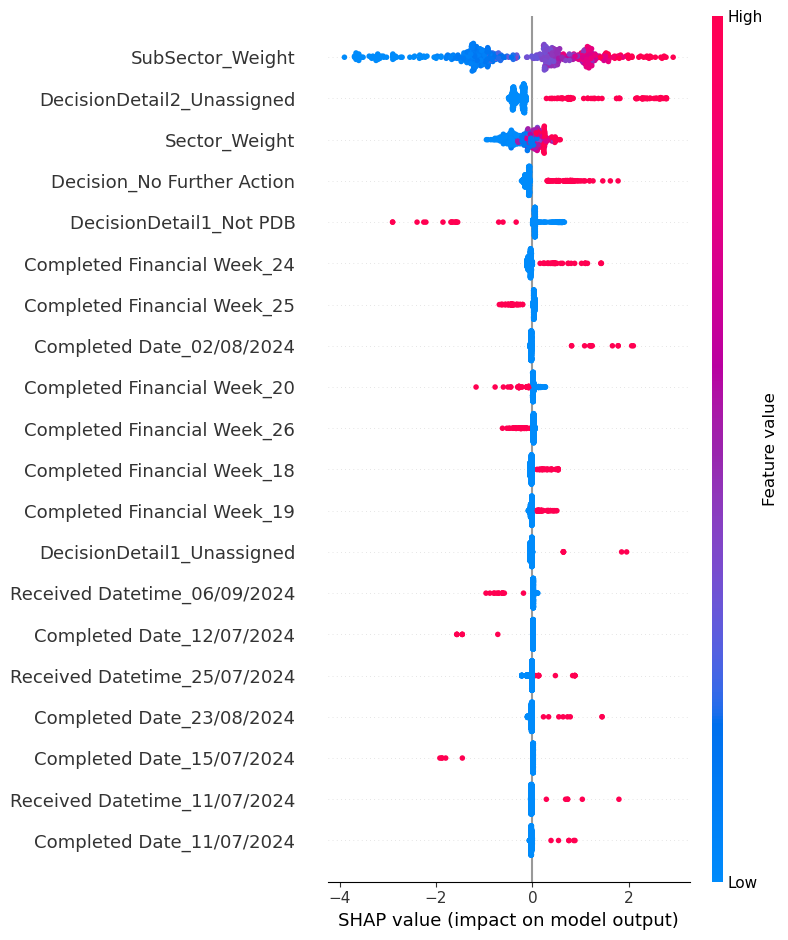

In [9]:

# Create generic feature names for X_test columns
feature_names = X_encoded.columns
# Then use these when creating X_test_df
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_df)

print("Shapley plot:")
shap.summary_plot(shap_values, X_test_df)

The SHAP summary plot suggests that Sub Sector Weight, Sector Weight and Decision Detail Unassigned have the largest impact on the models predictions.

SubSector_Weights help the model decide which subsectors are more important by assigning higher values to key areas, ensuring predictions focus on the most impactful parts of the business.  For example, if a subsector like "Manufacturing" has a high cyber incident percentage, the model will pay more attention to it when making decisions.

The disperity between sector weight and sub sector weight can be accounted for by the large fluxuation in cyber incidents across sub sectors.  There are nearly 1000 different sub sectors in contrast to the 20 sectors, meaning there will naturally be a variation of cyber incident percentage across the sub sector data.